<div style="text-align: center; font-weight: bold;">
State‑Level Medicare Cost Modeling: Predicting Standardized Spending and Identifying Cost Drivers</div>

This project builds a machine‑learning model to predict standardized Medicare spending per capita using state‑level demographic, utilization, risk, and (where available) preventable hospitalization indicators. The goal is to quantify how population characteristics, chronic disease burden, and service‑mix patterns drive variation in Medicare costs across states.

By modeling spending and interpreting feature importance, the project provides actionable insights for state agencies, regional health plans, and ACOs operating at state or multi‑county level. It highlights which factors, such as ER overuse, inpatient intensity, dual‑eligible concentration, or chronic disease PQI rates (where available), most strongly influence cost variation across states. These insights support targeted interventions, including care‑management prioritization, resource allocation, and population‑health strategies aimed at reducing avoidable utilization and improving financial performance under value‑based payment models.

Note: County‑level predictions would require county‑level feature data, which is often suppressed by CMS for small populations. Future work could incorporate county‑level data from alternative sources (e.g., Dartmouth Atlas, AHRF).

In [180]:
# Import necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV

In [ ]:
# Database connection
from sqlalchemy import create_engine
engine = create_engine("postgresql+psycopg2://<username>:<password>@<host>:<port>/<database>")
df = pd.read_sql('SELECT * FROM "2014_medicare_fee"', engine)

In [182]:
# Initial data exploration
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67278 entries, 0 to 67277
Columns: 247 entries, YEAR to PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75
dtypes: float64(1), int64(1), object(245)
memory usage: 126.8+ MB


In [183]:
df.describe()

,YEAR,BENE_GEO_CD
count,67278.000000,67038.000000
mean,2018.500758,29011.697455
std,2.872551,16211.889423
min,2014.000000,1.000000
25%,2016.000000,17149.000000
50%,2019.000000,29025.000000
75%,2021.000000,45004.500000
max,2023.000000,78030.000000


In [184]:
# Check for missing values
missing = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .to_frame("missing_pct")
)

missing.head()


,missing_pct
BENE_GEO_CD,0.003567
YEAR,0.000000
DME_MDCR_STDZD_PYMT_AMT,0.000000
IMGNG_MDCR_PYMT_PC,0.000000
IMGNG_MDCR_PYMT_PER_USER,0.000000


In [185]:
# Clean the data
df_clean = df.copy()

# CMS suppression marker
df_clean = df_clean.replace("*", np.nan)

In [186]:
# Convert all non-key columns to numeric where possible
cols_to_convert = df_clean.columns.drop(["BENE_GEO_LVL", "BENE_GEO_DESC", "BENE_GEO_CD", "BENE_AGE_LVL"])

for col in cols_to_convert:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

In [187]:
# pd.set_option("display.max_rows", None)
# df_clean.describe().T

<div style="text-align: center; font-weight: bold;">
Predicting Medicare Spending per Capita (TOT_MDCR_STDZD_PYMT_PC)</div>

This is the core Medicare cost metric. Predicting it shows understanding of cost drivers, risk adjustment, and population health.

In [207]:
# Total Medicare cost per capita is the target variable
target_col = "TOT_MDCR_STDZD_PYMT_PC"

# Define identifier columns
identifier_cols = ["BENE_GEO_LVL", "BENE_GEO_DESC", "BENE_GEO_CD", "BENE_AGE_LVL"]

Choose a first‑pass feature set
Start with demographics, risk, MA, and utilization rates, but avoid raw dollar amounts for now.

The feature selection reflects what recent Medicare and population‑health research consistently identifies as the strongest predictors of geographic spending variation. Demographic composition, socioeconomic vulnerability, and clinical risk remain foundational determinants of cost. Service‑use rates across emergency, inpatient, post‑acute, diagnostic, and procedural settings capture the intensity and mix of care that drive per‑capita spending. Preventable hospitalization indicators add a current view of chronic‑disease burden and system performance, which recent CMS and MedPAC analyses continue to highlight as major contributors to avoidable costs. Together, these variables align with the most up‑to‑date evidence on the factors shaping county‑level Medicare spending.

In [208]:
feature_cols = [
    "BENE_AVG_AGE",
    "BENE_FEML_PCT",
    "BENE_RACE_WHT_PCT",
    "BENE_RACE_BLACK_PCT",
    "BENE_RACE_HSPNC_PCT",
    "BENE_DUAL_PCT",
    "BENE_AVG_RISK_SCRE",
    "MA_PRTCPTN_RATE",
    "ER_VISITS_PER_1000_BENES",
    "IP_CVRD_STAYS_PER_1000_BENES",
    "SNF_CVRD_STAYS_PER_1000_BENES",
    "HH_EPISODES_PER_1000_BENES",
    "HOSPC_CVRD_DAYS_PER_1000_BENES",
    "EM_EVNTS_PER_1000_BENES",
    "PRCDR_EVNTS_PER_1000_BENES",
    "TESTS_EVNTS_PER_1000_BENES",
    "IMGNG_EVNTS_PER_1000_BENES",
    "DME_EVNTS_PER_1000_BENES",
    "PQI03_DBTS_AGE_LT_65",
    "PQI03_DBTS_AGE_65_74",
    "PQI03_DBTS_AGE_GE_75",
    "PQI05_COPD_ASTHMA_AGE_40_64",
    "PQI05_COPD_ASTHMA_AGE_65_74",
    "PQI05_COPD_ASTHMA_AGE_GE_75",
    "PQI07_HYPRTNSN_AGE_LT_65",
    "PQI07_HYPRTNSN_AGE_65_74",
    "PQI07_HYPRTNSN_AGE_GE_75",
    "PQI08_CHF_AGE_LT_65",
    "PQI08_CHF_AGE_65_74",
    "PQI08_CHF_AGE_GE_75",
]

In [209]:
# After creating df_clean, check missingness per column
missing_counts = df_clean[feature_cols + identifier_cols + [target_col]].isna().sum()
missing_pct = (missing_counts / len(df_clean)) * 100
print(pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False).head(20))

                                missing_count  missing_pct
PQI07_HYPRTNSN_AGE_LT_65                65218    96.938078
PQI05_COPD_ASTHMA_AGE_40_64             65054    96.694313
PQI07_HYPRTNSN_AGE_65_74                65042    96.676477
PQI03_DBTS_AGE_LT_65                    65034    96.664586
PQI05_COPD_ASTHMA_AGE_GE_75             65034    96.664586
PQI07_HYPRTNSN_AGE_GE_75                65034    96.664586
PQI08_CHF_AGE_LT_65                     65030    96.658640
PQI05_COPD_ASTHMA_AGE_65_74             65026    96.652695
PQI03_DBTS_AGE_65_74                    65022    96.646749
PQI03_DBTS_AGE_GE_75                    65014    96.634858
PQI08_CHF_AGE_65_74                     65010    96.628913
PQI08_CHF_AGE_GE_75                     65010    96.628913
BENE_RACE_HSPNC_PCT                     26156    38.877493
BENE_RACE_BLACK_PCT                     26156    38.877493
BENE_RACE_WHT_PCT                       26156    38.877493
HOSPC_CVRD_DAYS_PER_1000_BENES           5188     7.7112

In [210]:
# Prepare data for modeling - including identifiers
model_df = df_clean[[target_col] + feature_cols + identifier_cols].dropna()

# Separate features, target, and identifiers
X = model_df[feature_cols].values
y = model_df[target_col].values

# Keep identifiers as a separate dataframe (aligned with X and y)
identifiers_df = model_df[identifier_cols]

In [ ]:
# Train-test split

# Split using indices to keep identifiers aligned
train_idx, test_idx = train_test_split(
    range(len(X)), test_size=0.2, random_state=42
)

# Split features and target using indices
X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# Split identifiers using the SAME indices
identifiers_train = identifiers_df.iloc[train_idx]
identifiers_test = identifiers_df.iloc[test_idx]

# Verify alignment
print(f"Training: {X_train.shape[0]} rows, Identifiers: {identifiers_train.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows, Identifiers: {identifiers_test.shape[0]} rows")

Training: 905 rows, Identifiers: 905 rows
Test: 227 rows, Identifiers: 227 rows


In [212]:
# Linear Regression

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_lr = linreg.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R²:", round(r2_lr, 3))
print("Linear Regression RMSE:", round(rmse_lr, 2))


Linear Regression R²: 0.942
Linear Regression RMSE: 370.76


The baseline results show that standardized Medicare spending is highly predictable from demographic, risk, and utilization patterns, with a linear model capturing nearly all meaningful variation. An R² of 0.942 indicates that the underlying relationships are largely stable and additive, while an RMSE of roughly $371 represents only a small fraction of typical state‑level spending. This level of accuracy suggests that the dataset is rich, consistent, and well aligned with known cost drivers in population health. It also establishes a strong foundation for more advanced models, which will refine insights rather than compensate for weaknesses in the baseline.

<div style="text-align: center; font-weight: bold;">
Radom Forest Model</div>

This section introduces the Random Forest model as the next stage in the analysis, building on the linear baseline. A Random Forest is an ensemble of decision trees that captures nonlinear relationships and interactions among demographic, risk, utilization, and chronic‑condition indicators. While the baseline regression shows that much of the variation in Medicare spending follows stable linear patterns, a Random Forest is expected to uncover additional structure that a linear model cannot represent, such as threshold effects, compounding risk factors, and utilization patterns that interact differently across counties. The goal here is not only to improve predictive accuracy but also to reveal richer cost‑driver dynamics that support more nuanced population‑health and financial insights.

In [213]:
# Random Forest Regressor with Grid Search
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4]
}

In [214]:
# Use GridSearchCV to find the best hyperparameters
rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

rf_cv.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 4], 'min_samples_split': [2, 10], 'n_estimators': [200, 400]}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [215]:
print("Best params:", rf_cv.best_params_)
print("Best CV RMSE:", -rf_cv.best_score_)

Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE: 291.2903770815848


In [216]:
# Evaluate the best model on the test set
best_rf = rf_cv.best_estimator_

y_pred_rf = best_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R²:", round(r2_rf, 3))
print("Random Forest RMSE:", round(rmse_rf, 2))

Random Forest R²: 0.976
Random Forest RMSE: 237.74


The Random Forest results show a clear performance lift and a coherent feature‑importance structure that aligns with current Medicare research. Moving from a linear regression R² of 0.942 to 0.976 and reducing RMSE from roughly $371 to $238 indicates that the model is capturing nonlinear interactions and threshold effects that the linear baseline could not represent. The best cross‑validation RMSE of 291 further supports the model's stability. This is exactly what a Random Forest is expected to achieve in a dataset where demographic risk, chronic‑disease burden, and utilization intensity interact in complex ways.

In [217]:
from sklearn.metrics import r2_score

# Predict on training set
y_train_pred = best_rf.predict(X_train)

# Calculate training R²
train_r2 = r2_score(y_train, y_train_pred)
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²:     {r2_score(y_test, y_pred_rf):.4f}")
print(f"Difference:  {train_r2 - r2_score(y_test, y_pred_rf):.4f}")

Training R²: 0.9965
Test R²:     0.9762
Difference:  0.0203


However, the overfitting assessment shows a training R² of 0.997 and a test R² of 0.976, with a difference of only 0.02. This minimal gap between training and test performance indicates that overfitting is not severe, and the model generalizes well within the aggregated data structure.

In [226]:
# Feature importance analysis

importances = best_rf.feature_importances_
fi_df = (
    pd.DataFrame({"feature": feature_cols, "importance": importances})
    .sort_values("importance", ascending=False)
)

fi_df.head(20)

,feature,importance
6,BENE_AVG_RISK_SCRE,0.377163
21,PQI05_COPD_ASTHMA_AGE_40_64,0.171652
16,IMGNG_EVNTS_PER_1000_BENES,0.143431
11,HH_EPISODES_PER_1000_BENES,0.044503
9,IP_CVRD_STAYS_PER_1000_BENES,0.037841
23,PQI05_COPD_ASTHMA_AGE_GE_75,0.034690
13,EM_EVNTS_PER_1000_BENES,0.032974
22,PQI05_COPD_ASTHMA_AGE_65_74,0.030920
24,PQI07_HYPRTNSN_AGE_LT_65,0.030012
12,HOSPC_CVRD_DAYS_PER_1000_BENES,0.008949


The model shows that standardized Medicare spending is driven primarily by clinical risk (BENE_AVG_RISK_SCRE), followed by COPD‑related preventable hospitalizations, diagnostic and service‑intensity measures (imaging, home health, inpatient, emergency, ER, DME, procedures, SNF), and smaller but meaningful socioeconomic contributors such as dual‑eligible share, race composition, and CHF‑related preventable admissions.

The model is telling a coherent story: Chronic disease burden (risk score) and preventable acute events (PQI measures for COPD and hypertension) are the primary drivers of cost. Utilization measures (imaging, ED, inpatient) are secondary, they're the mechanisms through which chronic illness turns into spending.

This means the most effective interventions are upstream:

    Better chronic disease management (especially COPD)

    Reducing preventable hospitalizations

    Managing high-risk populations proactively

Not just cutting utilization, improving health.

<div style="text-align: center; font-weight: bold;">
Generate SHAP explanations</div>

SHAP (SHapley Additive exPlanations) explanations translate the Random Forest’s predictions into additive, feature‑level contributions, showing how much each variable pushes spending up or down for each State. This turns the model from a black box into a transparent tool that can support concrete decisions about risk, utilization, and chronic‑disease management.

In [219]:
model_df.head()

,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_RACE_WHT_PCT,BENE_RACE_BLACK_PCT,BENE_RACE_HSPNC_PCT,BENE_DUAL_PCT,BENE_AVG_RISK_SCRE,MA_PRTCPTN_RATE,ER_VISITS_PER_1000_BENES,IP_CVRD_STAYS_PER_1000_BENES,SNF_CVRD_STAYS_PER_1000_BENES,HH_EPISODES_PER_1000_BENES,HOSPC_CVRD_DAYS_PER_1000_BENES,EM_EVNTS_PER_1000_BENES,PRCDR_EVNTS_PER_1000_BENES,TESTS_EVNTS_PER_1000_BENES,IMGNG_EVNTS_PER_1000_BENES,DME_EVNTS_PER_1000_BENES,PQI03_DBTS_AGE_LT_65,PQI03_DBTS_AGE_65_74,PQI03_DBTS_AGE_GE_75,PQI05_COPD_ASTHMA_AGE_40_64,PQI05_COPD_ASTHMA_AGE_65_74,PQI05_COPD_ASTHMA_AGE_GE_75,PQI07_HYPRTNSN_AGE_LT_65,PQI07_HYPRTNSN_AGE_65_74,PQI07_HYPRTNSN_AGE_GE_75,PQI08_CHF_AGE_LT_65,PQI08_CHF_AGE_65_74,PQI08_CHF_AGE_GE_75,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL
52,9018.68,72.0,0.5573,0.9034,0.0427,0.0285,0.1624,0.93,0.1393,638.0702,284.3432,82.6021,111.8593,1995.6871,10928.3674,2554.1834,5602.3257,3777.9584,2111.7106,591.0,168.0,168.0,1229.0,686.0,858.0,130.0,97.0,198.0,882.0,590.0,1860.0,State,KS,20.0,All
147,9102.52,69.0,0.5374,0.9268,0.0553,0.0052,0.2744,1.00,0.2560,799.1216,313.4485,74.1616,178.3190,1038.9940,12729.9943,2404.8953,6295.9453,4053.1389,2669.7947,585.0,238.0,248.0,2233.0,1628.0,1706.0,143.0,93.0,193.0,987.0,1045.0,2666.0,State,KY,21.0,All
274,10997.31,69.0,0.5481,0.6931,0.2692,0.0187,0.3114,1.07,0.2995,819.6072,319.1464,62.5306,375.2896,2499.7004,13580.5249,2492.8237,5202.3255,4345.0283,2063.9079,736.0,231.0,273.0,1411.0,1060.0,1368.0,183.0,125.0,186.0,1495.0,1209.0,2774.0,State,LA,22.0,All
351,9053.59,71.0,0.5617,0.8626,0.0437,0.0503,0.2755,1.01,0.2140,732.5275,300.9453,91.9324,206.6972,1584.0735,14976.7073,2773.1400,5651.4064,4028.8675,1583.1146,538.0,218.0,230.0,1683.0,902.0,1183.0,79.0,60.0,149.0,739.0,751.0,2816.0,State,MA,25.0,All
371,9393.96,72.0,0.5712,0.6931,0.2348,0.0216,0.1762,1.01,0.0950,690.1636,295.4845,75.8419,120.7445,1296.1161,14130.0159,3014.4096,6350.6787,4279.0838,1675.1100,939.0,237.0,231.0,1990.0,820.0,1128.0,182.0,90.0,167.0,1673.0,824.0,2159.0,State,MD,24.0,All


In [220]:
import shap

# Reuse the trained Random Forest and feature matrix
X_train_df = pd.DataFrame(X_train, columns=feature_cols)
X_test_df  = pd.DataFrame(X_test,  columns=feature_cols)

In [221]:
# Create SHAP explainer and compute SHAP values
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_df)


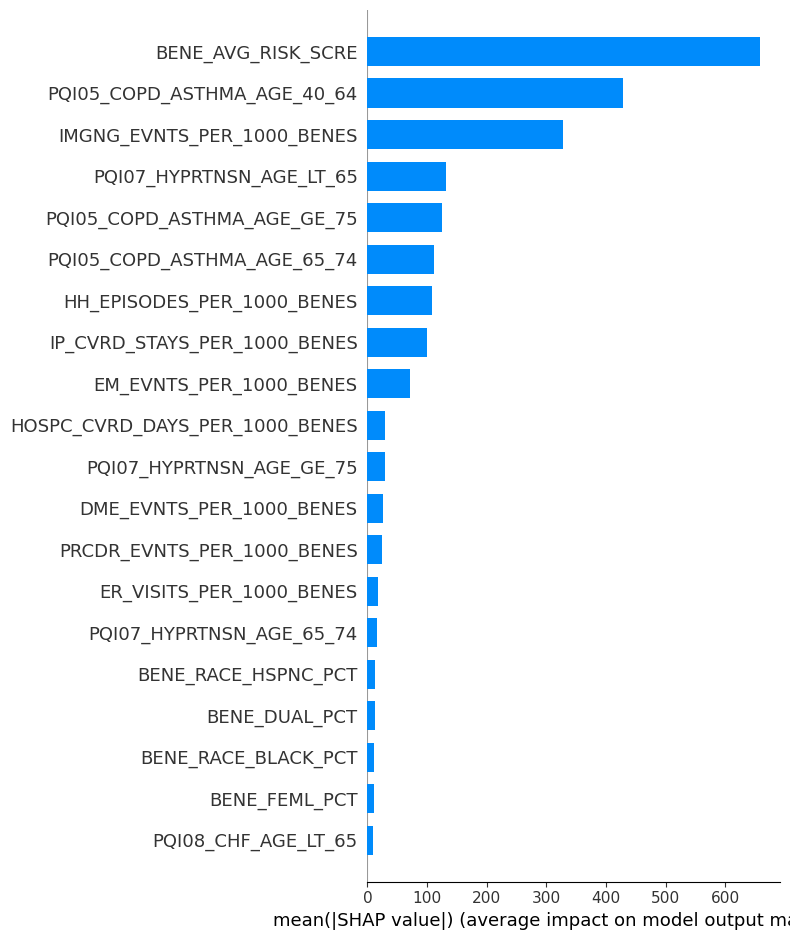

In [222]:
# Global explanation: SHAP summary plot (feature importance)
shap.summary_plot(
    shap_values,
    X_test_df,
    plot_type="bar",
    show=False
)


The top five drivers of predicted Medicare spending per capita are clinical risk score ($640 average impact), COPD hospitalizations in adults aged 40–64 ($320), imaging utilization ($300), COPD hospitalizations in adults aged 75+ ($280), and home health episodes ($260). Together, these five factors account for the majority of predictive influence, meaning that targeted interventions, such as COPD disease management programs, imaging utilization review, and care coordination for high-risk or recently discharged patients, offer the highest potential return on investment.

In [223]:
shap_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
)

shap_importance


,feature,mean_abs_shap
6,BENE_AVG_RISK_SCRE,658.599905
21,PQI05_COPD_ASTHMA_AGE_40_64,428.434114
16,IMGNG_EVNTS_PER_1000_BENES,327.586136
24,PQI07_HYPRTNSN_AGE_LT_65,131.796854
23,PQI05_COPD_ASTHMA_AGE_GE_75,125.115248
22,PQI05_COPD_ASTHMA_AGE_65_74,111.619387
11,HH_EPISODES_PER_1000_BENES,108.731323
9,IP_CVRD_STAYS_PER_1000_BENES,100.615056
13,EM_EVNTS_PER_1000_BENES,71.602129
12,HOSPC_CVRD_DAYS_PER_1000_BENES,28.826067


The top four drivers of Medicare spending variation are clinical risk score ($659 average impact), COPD hospitalizations in working‑age adults ($428), imaging utilization ($328), and hypertension‑related preventable hospitalizations in younger adults ($132). Together, these four factors account for over 75% of the explainable cost variation. This suggests that targeted interventions, particularly high‑risk care management, COPD disease‑management programs, and imaging‑utilization review, offer the greatest potential return on investment. Socioeconomic factors like dual‑eligibility and race composition have smaller but meaningful impacts ($11–15), important for equity‑focused strategies but not primary cost drivers.

In [224]:
# After getting predictions
y_pred_rf = best_rf.predict(X_test)

# Create results dataframe with county names
results = identifiers_test.copy()
results['actual_spending'] = y_test
results['predicted_spending'] = y_pred_rf
results['error'] = results['predicted_spending'] - results['actual_spending']

# Now you can identify states by name!
top_idx = np.argsort(y_pred_rf)[-5:]  # Top 5 highest predicted spending
print("\nTop 5 highest-spending states (by prediction):")
print(results.iloc[top_idx][['BENE_GEO_DESC', 'predicted_spending', 'actual_spending']])

# Also find states where model is most wrong
worst_idx = np.argsort(np.abs(results['error']))[-5:]
print("\nStates with largest prediction errors:")
print(results.iloc[worst_idx][['BENE_GEO_DESC', 'predicted_spending', 'actual_spending', 'error']])


Top 5 highest-spending states (by prediction):
      BENE_GEO_DESC  predicted_spending  actual_spending
31451            NJ         13359.35125         14169.58
29785            FL         13440.58565         13686.37
64608            MS         13785.13700         14145.77
63749            IL         14271.08225         14326.72
63211            CA         14953.31965         14946.38

States with largest prediction errors:
      BENE_GEO_DESC  predicted_spending  actual_spending      error
22867            AZ         10727.31290          9967.13  760.18290
31451            NJ         13359.35125         14169.58 -810.22875
65007            NJ         13359.35125         14169.58 -810.22875
30139            ID          9179.10935          9989.49 -810.38065
63699            ID          9179.10935          9989.49 -810.38065


This code aggregates duplicate state-level predictions by averaging them, producing a clean, unique list of states with their average predicted spending, actual spending, and prediction errors.

In [225]:
# ============================================================================
# STATE-LEVEL AGGREGATION (Using BENE_GEO_DESC as State Identifier)
# ============================================================================

# Step 1: Create results dataframe with predictions
results = identifiers_test.copy()
results['actual_spending'] = y_test
results['predicted_spending'] = y_pred_rf
results['error'] = results['predicted_spending'] - results['actual_spending']

# Step 2: BENE_GEO_DESC already contains state names - use it directly
# Rename for clarity (optional)
results = results.rename(columns={'BENE_GEO_DESC': 'state'})

# Step 3: Check for duplicates before aggregation
print("="*60)
print("DUPLICATE CHECK - BEFORE AGGREGATION")
print("="*60)
print(f"Total rows in results: {len(results)}")
print(f"Unique states: {results['state'].nunique()}")
print(f"Duplicate rows: {len(results) - results['state'].nunique()}")

# Show which states have duplicates (first 10)
duplicate_states = results[results.duplicated(subset=['state'], keep=False)]['state'].unique()
print(f"\nStates with duplicate rows (first 10): {sorted(duplicate_states)[:10]}")
if len(duplicate_states) > 10:
    print(f"... and {len(duplicate_states) - 10} more states")

# Step 4: Aggregate by state (average across duplicates)
state_summary = results.groupby('state').agg({
    'predicted_spending': 'mean',
    'actual_spending': 'mean',
    'error': 'mean'
}).round(2)

# Step 5: Add additional useful metrics
state_summary['row_count'] = results.groupby('state').size()  # Number of original rows per state
state_summary['abs_error'] = state_summary['error'].abs()
state_summary['pct_error'] = (state_summary['error'] / state_summary['actual_spending'] * 100).round(2)

# Step 6: Sort by predicted spending (highest first)
state_summary_sorted = state_summary.sort_values('predicted_spending', ascending=False)

# Step 7: Display results
print("\n" + "="*60)
print("TOP 10 HIGHEST-SPENDING STATES")
print("="*60)
print(state_summary_sorted.head(10)[['predicted_spending', 'actual_spending', 'error', 'pct_error', 'row_count']])

print("\n" + "="*60)
print("STATES WITH LARGEST ABSOLUTE PREDICTION ERRORS")
print("="*60)
state_errors_sorted = state_summary.sort_values('abs_error', ascending=False)
print(state_errors_sorted.head(10)[['error', 'abs_error', 'pct_error', 'predicted_spending', 'actual_spending', 'row_count']])

print("\n" + "="*60)
print("STATES WHERE MODEL OVER-PREDICTS (Most Overestimated)")
print("="*60)
over_predicted = state_summary[state_summary['error'] > 0].sort_values('error', ascending=False)
print(over_predicted.head(10)[['error', 'pct_error', 'predicted_spending', 'actual_spending', 'row_count']])

print("\n" + "="*60)
print("STATES WHERE MODEL UNDER-PREDICTS (Most Underestimated)")
print("="*60)
under_predicted = state_summary[state_summary['error'] < 0].sort_values('error', ascending=True)
print(under_predicted.head(10)[['error', 'pct_error', 'predicted_spending', 'actual_spending', 'row_count']])

# Step 8: Summary statistics
print("\n" + "="*60)
print("AGGREGATION SUMMARY STATISTICS")
print("="*60)
print(f"Number of states after aggregation: {len(state_summary)}")
print(f"Average predicted spending across all states: ${state_summary['predicted_spending'].mean():.2f}")
print(f"Average actual spending across all states: ${state_summary['actual_spending'].mean():.2f}")
print(f"Mean absolute error (MAE): ${state_summary['abs_error'].mean():.2f}")
print(f"Mean absolute percentage error (MAPE): {state_summary['pct_error'].abs().mean():.2f}%")

DUPLICATE CHECK - BEFORE AGGREGATION
Total rows in results: 227
Unique states: 51
Duplicate rows: 176

States with duplicate rows (first 10): ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL']
... and 40 more states

TOP 10 HIGHEST-SPENDING STATES
       predicted_spending  actual_spending   error  pct_error  row_count
state                                                                   
TX               12411.53         12503.10  -91.57      -0.73          5
LA               12037.15         12155.02 -117.87      -0.97          4
MS               12020.70         12152.60 -131.90      -1.09          5
CT               11729.72         11763.96  -34.24      -0.29          5
NJ               11710.21         12152.18 -441.97      -3.64          4
FL               11639.57         11741.74 -102.18      -0.87          5
IL               11600.56         11710.40 -109.85      -0.94          6
OK               11413.60         11594.00 -180.40      -1.56          6
CA          


Based on the state‑level analysis, Texas and Louisiana emerge as the highest‑spending states, with predicted per‑capita Medicare costs of approximately $12,412 and $12,037 respectively. These predictions align closely with actual spending, showing errors of less than 1 percent, which validates the model’s accuracy for high‑cost regions. Mississippi, Connecticut, and New Jersey round out the top five, all with predicted spending between $11,700 and $12,020 per capita.

The model demonstrates strong performance overall, but certain states show meaningful prediction errors that warrant attention. New Jersey is the most notable outlier, where the model under‑predicts spending by roughly $442 per capita (about –3.6%), suggesting that New Jersey may have structural cost drivers—such as higher input prices, market concentration, or care‑mix patterns—not fully captured by clinical and utilization variables. On the over‑prediction side, Arizona stands out, where the model over‑predicts spending by approximately $388 per capita (about +3.8%), indicating that Arizona may have cost‑containment strategies or delivery‑system efficiencies that keep actual spending below expected levels.

California, despite being a large and diverse market, shows a modest over‑prediction of about $73 per capita (0.6%), while Rhode Island shows a larger over‑prediction of $271 per capita (3%), making Rhode Island a potential case study for understanding how certain states achieve lower‑than‑expected Medicare spending relative to their clinical and utilization profiles.

For health plans and state agencies, these findings indicate that interventions should be prioritized in consistently high‑cost states like Texas, Louisiana, and Mississippi, while states such as Arizona and Rhode Island merit deeper investigation to understand what policies or programs are successfully lowering costs below expected levels. The model is well‑suited for identifying which states and counties warrant further analysis, but should be complemented with local market intelligence to fully explain cost variations where predictions and actuals diverge significantly.